In [84]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib as plt
import warnings

warnings.filterwarnings('ignore')

In [85]:
df=pd.read_csv("heart.csv")

In [86]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## EDA

In [87]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [88]:
df.shape

(918, 12)

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [90]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


### EDA and Data Cleaning both at same time 

In [91]:
df.duplicated().sum()

np.int64(0)

In [92]:
df['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [93]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

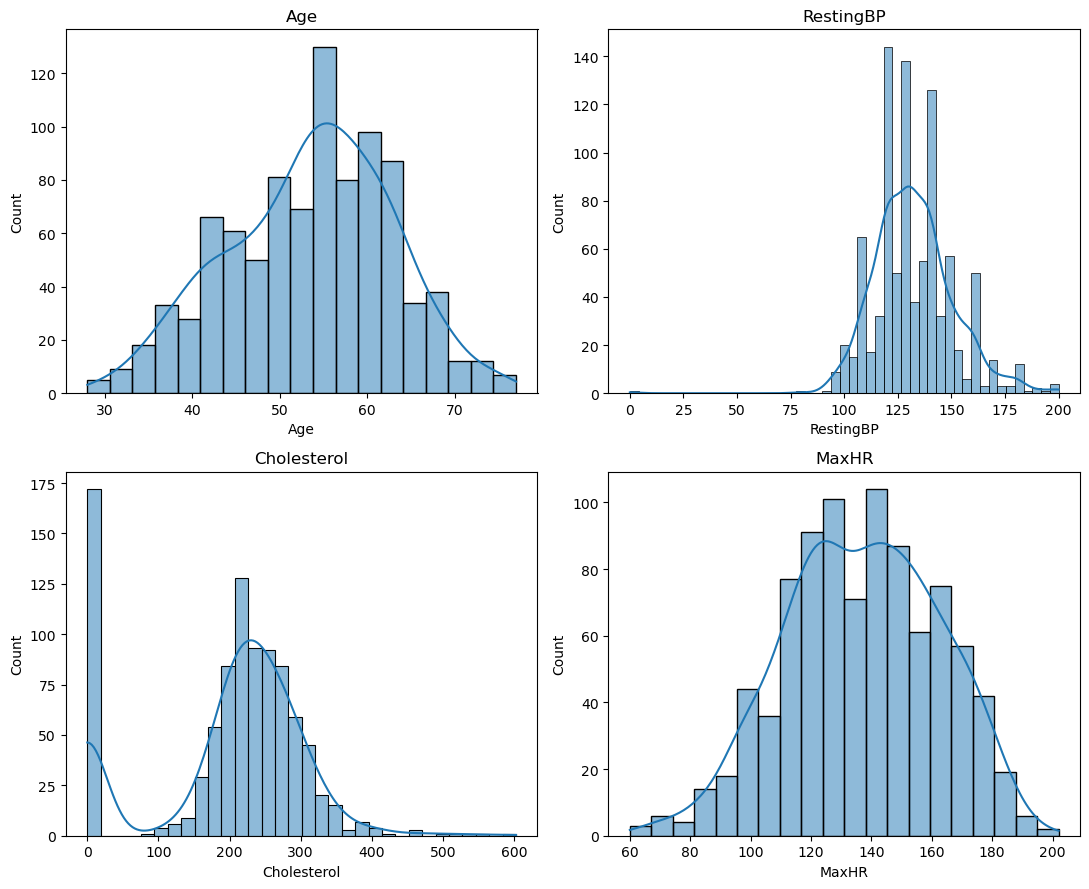

In [94]:
#problem in null when it has 0 null value there is also problem 
import matplotlib.pyplot as plt
import seaborn as sns

def plotting(var, num):
    plt.subplot(2, 2, num)
    sns.histplot(df[var], kde=True)
    plt.title(var)

plt.figure(figsize=(11,9))

plotting('Age', 1)
plotting('RestingBP', 2)
plotting('Cholesterol', 3)
plotting('MaxHR', 4)

plt.tight_layout()
plt.show()


In [95]:
df['Cholesterol'].value_counts()
#the data is wrong because 0 chelesotrl dont exist every human has some amoiunt of it

Cholesterol
0      172
254     11
223     10
220     10
230      9
      ... 
392      1
316      1
153      1
466      1
131      1
Name: count, Length: 222, dtype: int64

In [96]:
ch_mean=df.loc[df['Cholesterol']!=0,'Cholesterol']

In [97]:
ch_mean

0      289
1      180
2      283
3      214
4      195
      ... 
913    264
914    193
915    131
916    236
917    175
Name: Cholesterol, Length: 746, dtype: int64

In [98]:
# compute mean excluding zeros
ch_mean = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].mean()

# replace zeros with mean
df['Cholesterol'] = df['Cholesterol'].replace(0, ch_mean)

# round to 2 decimal places
df['Cholesterol'] = df['Cholesterol'].round(2)


In [99]:
# compute mean excluding zeros
resting_bp_mean = df.loc[df['RestingBP'] != 0, 'RestingBP'].mean()

# replace zeros with mean
df['RestingBP'] = df['RestingBP'].replace(0, ch_mean)

# round to 2 decimal places
df['RestingBP'] = df['RestingBP'].round(2)


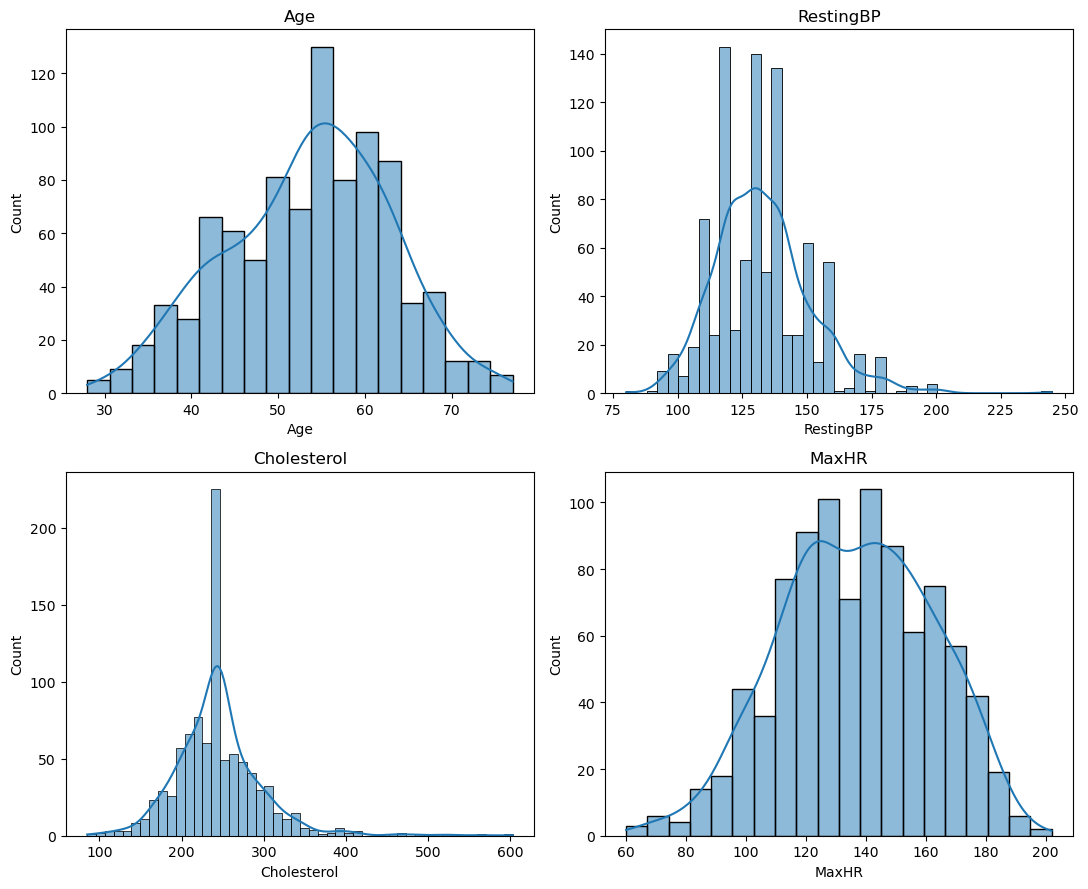

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

def plotting(var, num):
    plt.subplot(2, 2, num)
    sns.histplot(df[var], kde=True)
    plt.title(var)

plt.figure(figsize=(11,9))

plotting('Age', 1)
plotting('RestingBP', 2)
plotting('Cholesterol', 3)
plotting('MaxHR', 4)

plt.tight_layout()
plt.show()

## Categorical Data Analysis

In [101]:
import sheryanalysis as sh
sh.analyze(df)


ModuleNotFoundError: No module named 'sheryanalysis'

<Axes: xlabel='Sex', ylabel='count'>

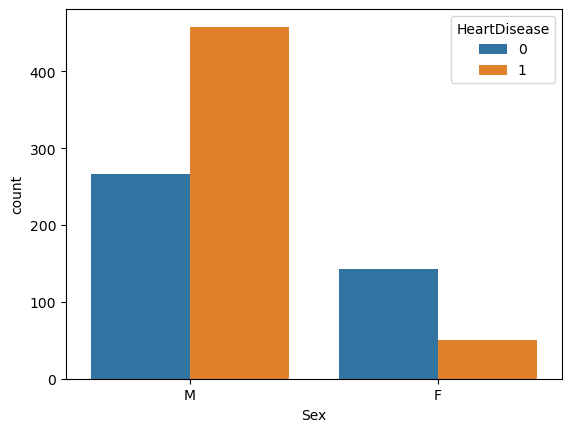

In [102]:
sns.countplot(x=df['Sex'],hue=df['HeartDisease'])

<Axes: xlabel='ChestPainType', ylabel='count'>

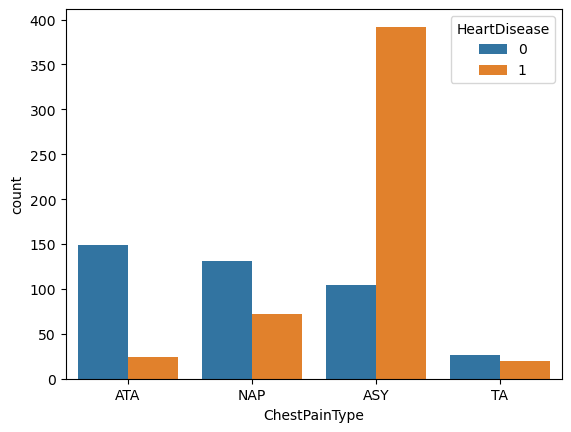

In [103]:
sns.countplot(x=df['ChestPainType'],hue=df['HeartDisease'])

<Axes: xlabel='FastingBS', ylabel='count'>

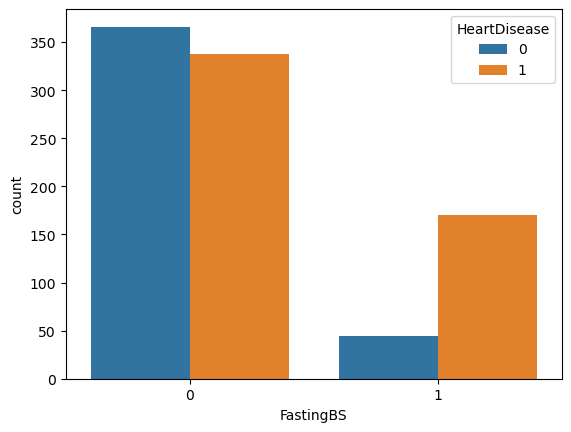

In [104]:
sns.countplot(x=df['FastingBS'],hue=df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

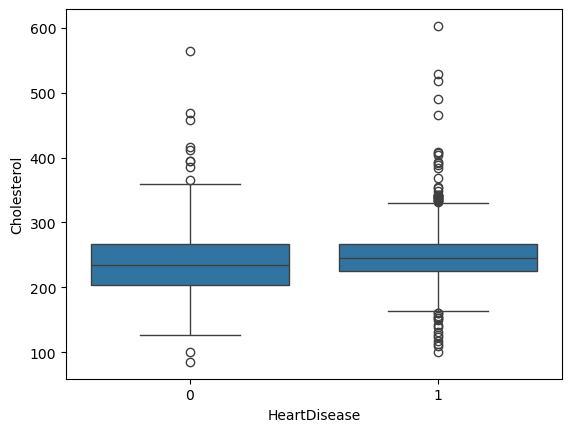

In [105]:
#compare numeric and categorical ddata
sns.boxplot(x='HeartDisease',y='Cholesterol' , data=df)

<Axes: xlabel='Sex', ylabel='Age'>

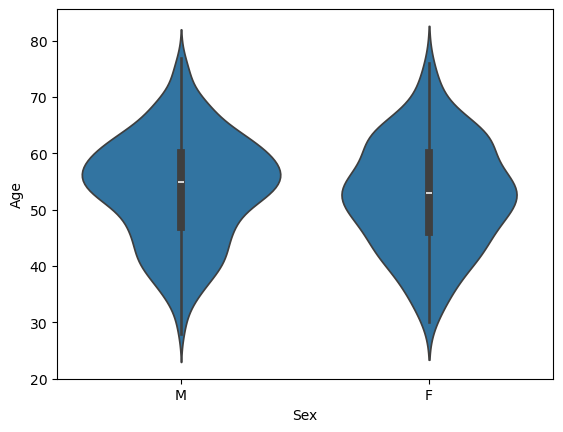

In [106]:
#violin pplotting
sns.violinplot( x='Sex',y='Age' , data=df)

## Data Pre-Processing And Cleaning


In [107]:
# we need dummies first for preprocessing
df_encode=pd.get_dummies(df,drop_first=True)

In [108]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144.0,193.0,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130.0,131.0,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130.0,236.0,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [109]:
df_encode=df_encode.astype(int)

In [110]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [111]:
#standard scaling
from sklearn.preprocessing import StandardScaler
numerical_cols = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']

scaler = StandardScaler()  # not "scalar"
df_encode[numerical_cols] = scaler.fit_transform(df_encode[numerical_cols])

df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.399826,0.834754,0,1.382928,-0.727592,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.489614,-1.210675,0,0.754157,0.282891,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.145068,0.722161,0,-1.525138,-0.727592,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.290847,-0.572651,0,-1.132156,0.282891,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.944720,-0.929194,0,-0.581981,-0.727592,0,1,0,1,0,1,0,0,0,1


## Feature Extraction

In [112]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [113]:
df=df.drop_duplicates()
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110.0,264.0,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144.0,193.0,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130.0,131.0,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130.0,236.0,0,LVH,174,N,0.0,Flat,1


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    float64
 4   Cholesterol     918 non-null    float64
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 86.2+ KB


In [115]:
(df['Cholesterol']>df['Cholesterol'].mean()).astype(int
                                                )
#Compares every age to the median, creating a Booleanall Series:
#Age > median → True
#Age ≤ median → False

0      1
1      0
2      1
3      0
4      0
      ..
913    1
914    0
915    0
916    0
917    0
Name: Cholesterol, Length: 918, dtype: int64

In [116]:
df = pd.read_csv("heart.csv", header=None)
df.columns

Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], dtype='int64')

In [117]:
df = pd.get_dummies(df, columns=[2])
df

,0,1,3,4,5,6,7,8,9,10,11,2_ASY,2_ATA,2_ChestPainType,2_NAP,2_TA
0,Age,Sex,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,False,False,True,False,False
1,40,M,140,289,0,Normal,172,N,0,Up,0,False,True,False,False,False
2,49,F,160,180,0,Normal,156,N,1,Flat,1,False,False,False,True,False
3,37,M,130,283,0,ST,98,N,0,Up,0,False,True,False,False,False
4,48,F,138,214,0,Normal,108,Y,1.5,Flat,1,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
914,45,M,110,264,0,Normal,132,N,1.2,Flat,1,False,False,False,False,True
915,68,M,144,193,1,Normal,141,N,3.4,Flat,1,True,False,False,False,False
916,57,M,130,131,0,Normal,115,Y,1.2,Flat,1,True,False,False,False,False
917,57,F,130,236,0,LVH,174,N,0,Flat,1,False,True,False,False,False


In [118]:
df.head()

,0,1,3,4,5,6,7,8,9,10,11,2_ASY,2_ATA,2_ChestPainType,2_NAP,2_TA
0,Age,Sex,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,False,False,True,False,False
1,40,M,140,289,0,Normal,172,N,0,Up,0,False,True,False,False,False
2,49,F,160,180,0,Normal,156,N,1,Flat,1,False,False,False,True,False
3,37,M,130,283,0,ST,98,N,0,Up,0,False,True,False,False,False
4,48,F,138,214,0,Normal,108,Y,1.5,Flat,1,True,False,False,False,False


### Feature Engineering:  1) Binning
This binning also comes under this. Binning is also known as bucketing. 
Binning means that if I have a single age column, the model won't learn from just telling it "age"; you have to create another column to indicate that 0-14 are kids, 14-20 are teenagers, 20-30 are adults, etc. Like this, you have to categorise a column and tell the model.

Here are some examples:

In [119]:

# # Age groups
# bins = [0, 12, 17, 35, 60, float('inf')]
# labels = ['child', 'teen', 'young_adult', 'adult', 'senior']
# df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

# # Income groups
# bins = [0, 25000, 50000, 100000, float('inf')]
# labels = ['low', 'medium', 'high', 'very_high']
# df['income_group'] = pd.cut(df['income'], bins=bins, labels=labels)

# # Score grades
# bins = [0, 40, 60, 80, 100]
# labels = ['fail', 'average', 'good', 'excellent']
# df['grade'] = pd.cut(df['score'], bins=bins, labels=labels)


### 2) Encoding:

There are many ways to do feature engineering, but we will learn. Encoding because we are taught this one first 
Encoding means converting columns that are strings into Numbers or integers.  For example:

In [120]:
# df['sex']    = df['sex'].map({'male': 0, 'female': 1})
# df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})

In [121]:
df.head()

,0,1,3,4,5,6,7,8,9,10,11,2_ASY,2_ATA,2_ChestPainType,2_NAP,2_TA
0,Age,Sex,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,False,False,True,False,False
1,40,M,140,289,0,Normal,172,N,0,Up,0,False,True,False,False,False
2,49,F,160,180,0,Normal,156,N,1,Flat,1,False,False,False,True,False
3,37,M,130,283,0,ST,98,N,0,Up,0,False,True,False,False,False
4,48,F,138,214,0,Normal,108,Y,1.5,Flat,1,True,False,False,False,False


### FEATURE SCALING : 
1) STANDARD SCALING:
    If any data is in integers and it has a value assigned in integer format , so in standard scaling we range it from 0 to 1 ..
and the value will be between 0 to 1 range  for example here :


In [122]:

#    <!-- ages = [20, 30, 40, 50, 60] -->

# <!-- # Mean of ages = (20+30+40+50+60)/5 = 40
# Std of ages = 14.14 (roughly)

# Applying formula:
# age 20 → (20 - 40) / 14.14 = -1.41
# age 30 → (30 - 40) / 14.14 = -0.70
# age 40 → (40 - 40) / 14.14 =  0.00
# age 50 → (50 - 40) / 14.14 = +0.70
# age 60 → (60 - 40) / 14.14 = +1.41

# Scaled ages = [-1.41, -0.70, 0.00, +0.70, +1.41] -->

In [123]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [131]:
data={
    'age':[14,18,22,25],
    'salary':[2000,4000,5000,4444]
}
df2=pd.DataFrame(data)
print("before scaling ")
print(df2)

before scaling 
   age  salary
0   14    2000
1   18    4000
2   22    5000
3   25    4444


In [125]:
print("after applying scaling ")
scaler=StandardScaler()
df_scaled=scaler.fit_transform(df)
df_scaled=pd.DataFrame(df_scaled,columns=['age','salary'])

print(df_scaled)

after applying scaling 
        age    salary
0 -1.386952 -1.644931
1 -0.422116  0.122862
2  0.542720  1.006758
3  1.266348  0.515312


####  Thats how its done the value is ranged between 1 to 0 it has been converted into normal distribution


## Step 4 — When to Use Which Scaler?
```
YOUR DATA
    │
    ├── Has Outliers?
    │       │
    │       YES → Use Robust Scaler
    │       │
    │       NO
    │       │
    ├── Need values between 0 and 1?
    │       │
    │       YES → Use MinMax Scaler
    │       │
    │       NO
    │       │
    └── Normal Distribution?
            │
            YES → Use Standard Scaler ✅ (most common)

### FEATURE EXTRACTION

Feature Extraction = **Finding and keeping only the most useful columns**


#### Method 1 — Correlation (for numerical columns)
```
Correlation tells you:
→ How strongly two columns are related
→ Value is between -1 and +1

+1 = Perfect positive relation
 0 = No relation at all
-1 = Perfect negative relation

In [151]:
import pandas as pd 
import seaborn as sns 
import numpy as np 
import matplotlib.pyplot as plt 


In [144]:
df1=pd.DataFrame(df)
# To Find Correlation Between any column with the target column like we take aget_dataframes
correlation =df.corr() ['age'].sort_values(ascending=False)
print(correlation)

age       1.000000
salary    0.857133
Name: age, dtype: float64


#### Step 2 - Visualize correlation with heatmap




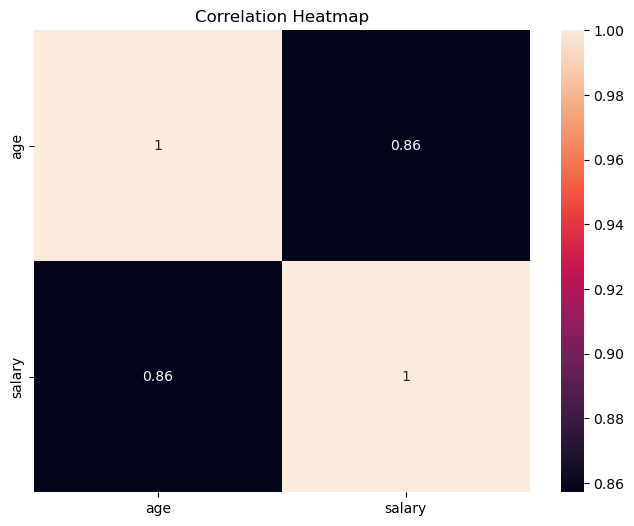

In [150]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8,6))
sns.heatmap(df1.corr(),annot=True)
plt.title('Correlation Heatmap')
plt.show()